# Restaurant Tipping Behavior Analysis

## Project Overview

Tipping is an important part of the restaurant experience, but tip amounts can be influenced by many factors, such as bill size, party size, dining time, and day of the week. In this project, we analyze a restaurant tipping dataset to understand what patterns appear in customer tipping behavior.

The goal is to use data analysis, visualization, and basic statistical testing to turn raw restaurant transaction data into clear business insights.

## Business Question

> **What factors are most closely related to customer tips, and how should a restaurant interpret those patterns?**

This project focuses on explaining tipping behavior instead of simply reporting charts. By comparing both tip amount and tip rate, we can avoid misleading conclusions caused by larger bills.

## Analysis Objectives

This project investigates whether tipping behavior changes based on:

1. Bill amount
2. Lunch vs dinner
3. Day of the week
4. Party size
5. Smoking status
6. Gender of the bill payer

We compare two key metrics:

- `tip`: the actual tip amount in dollars
- `tip_rate`: the tip amount divided by the total bill

This distinction is important because a larger bill can produce a larger tip amount even when the customer does not tip a higher percentage.

Why investigate tip rate?

> From domain experty,we should expect the tip rate is the similar disregard the total bill.

## Main Analysis Question

> **Are customers tipping differently across restaurant features, or are larger tips mostly explained by larger bills?**

## Methods Used

1. Data loading and initial inspection
2. Data cleaning and column selection
3. Feature engineering with `tip_rate`
4. Descriptive statistics and grouped summaries
5. Data visualization with histograms, scatter plots, bar charts, box plots, and a correlation heatmap
6. Hypothesis testing with Welch's two-sample t-test
7. Business-focused conclusion and recommendation


## 1. Import Libraries

We will use:

- `pandas` for working with table data
- `numpy` for numerical operations
- `matplotlib` for data visualization

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

## 2. Load the Dataset

Each row in this dataset represents one restaurant table.

The file we will use is `tips.csv`.

In [24]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person,Payer Name,CC Number,Payment ID
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49,Christy Cunningham,3560325168603410,Sun2959
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45,Douglas Tucker,4478071379779230,Sun4608
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00,Travis Walters,6011812112971322,Sun4458
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84,Nathaniel Harris,4676137647685994,Sun5260
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15,Tonya Carter,4832732618637221,Sun2251


## 3. Understand the Data

Before making charts, we should first understand the basic structure of the dataset:

- How many rows and columns are there?
- What is the data type of each column?
- Are there any missing values?
- Which columns are useful for analysis?
- Which columns should not be used because they contain personal or ID information?

In [25]:
print('Rows, Columns:', df.shape)

print('Data types:')
print(df.dtypes)

print('Missing values:')
print(df.isnull().sum())

Rows, Columns: (244, 11)
Data types:
total_bill          float64
tip                 float64
sex                     str
smoker                  str
day                     str
time                    str
size                  int64
price_per_person    float64
Payer Name              str
CC Number             int64
Payment ID              str
dtype: object
Missing values:
total_bill          0
tip                 0
sex                 0
smoker              0
day                 0
time                0
size                0
price_per_person    0
Payer Name          0
CC Number           0
Payment ID          0
dtype: int64


### Column Meaning

| Column | Meaning |
|---|---|
| `total_bill` | Total bill amount in dollars |
| `tip` | Tip amount in dollars |
| `sex` | Gender of the bill payer |
| `smoker` | Whether the table included smokers |
| `day` | Day of the week |
| `time` | Lunch or dinner |
| `size` | Number of people at the table |
| `price_per_person` | Average spending per person |
| `Payer Name` | Customer name; personal information |
| `CC Number` | Credit card number; personal information |
| `Payment ID` | Payment identifier |

For this project, we will remove personal information and ID columns so the analysis stays focused and responsible.

Now, we can delete CC Number. But i know, in different cultures, some clients can customize the CC Number. In this case, we should not remove the CC Number. However, i will discuss this question with my senior or supervisor. For now, we will delete it.

In [26]:
analysis_df = df.drop(columns=['Payer Name', 'CC Number', 'Payment ID'])
analysis_df.head()

,total_bill,tip,sex,smoker,day,time,size,price_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,8.49
1,10.34,1.66,Male,No,Sun,Dinner,3,3.45
2,21.01,3.50,Male,No,Sun,Dinner,3,7.00
3,23.68,3.31,Male,No,Sun,Dinner,2,11.84
4,24.59,3.61,Female,No,Sun,Dinner,4,6.15


## 4. Create a New Column: Tip Rate

Tip amount alone can be misleading.

Example:

- A customer with a $50 bill and a $5 tip has a 10% tip rate.
- A customer with a $10 bill and a $2 tip has a 20% tip rate.

So we will create a new column:

> `tip_rate = tip / total_bill`

This lets us compare how generous customers are relative to their bill size.

In [27]:
analysis_df['tip_rate'] = analysis_df['tip'] / analysis_df['total_bill']
analysis_df[['total_bill', 'tip', 'tip_rate']].head()

,total_bill,tip,tip_rate
0,16.99,1.01,0.059447
1,10.34,1.66,0.160542
2,21.01,3.50,0.166587
3,23.68,3.31,0.139780
4,24.59,3.61,0.146808


## 5. Basic Summary Statistics

Now we look at the main numerical columns.

In [28]:
analysis_df.describe().round(2)

,total_bill,tip,size,price_per_person,tip_rate
count,244.00,244.00,244.00,244.00,244.00
mean,19.79,3.00,2.57,7.89,0.16
std,8.90,1.38,0.95,2.91,0.06
min,3.07,1.00,1.00,2.88,0.04
25%,13.35,2.00,2.00,5.80,0.13
50%,17.80,2.90,2.00,7.26,0.15
75%,24.13,3.56,3.00,9.39,0.19
max,50.81,10.00,6.00,20.27,0.71


### First Observations

After running the code above, focus on these questions:

1. What is the average bill amount?
2. What is the average tip amount?
3. Is the maximum tip much higher than a typical tip?
4. What is the average tip rate?

In [29]:
print('Average bill:', round(analysis_df['total_bill'].mean(), 2))
print('Median bill:', round(analysis_df['total_bill'].median(), 2))
print('Average tip:', round(analysis_df['tip'].mean(), 2))
print('Median tip:', round(analysis_df['tip'].median(), 2))
print('Average tip rate:', round(analysis_df['tip_rate'].mean() * 100, 2), '%')

Average bill: 19.79
Median bill: 17.8
Average tip: 3.0
Median tip: 2.9
Average tip rate: 16.08 %


## 6. Question 1: What Is the Typical Tip Amount?

A histogram helps us see the distribution of tip amounts.

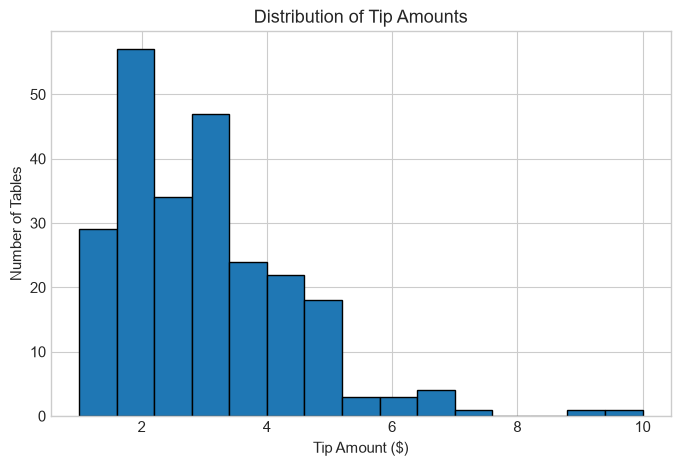

In [30]:
plt.hist(analysis_df['tip'], bins=15, edgecolor='black')
plt.title('Distribution of Tip Amounts')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Number of Tables')
plt.show()

### Interpretation

Most tips are around $2 to $4. Very high tips are less common. This means tip amounts are not evenly spread out; a few large tips can pull the average upward.

## 7. Question 2: Do Larger Bills Usually Receive Larger Tips?

A scatter plot helps us compare `total_bill` and `tip`.

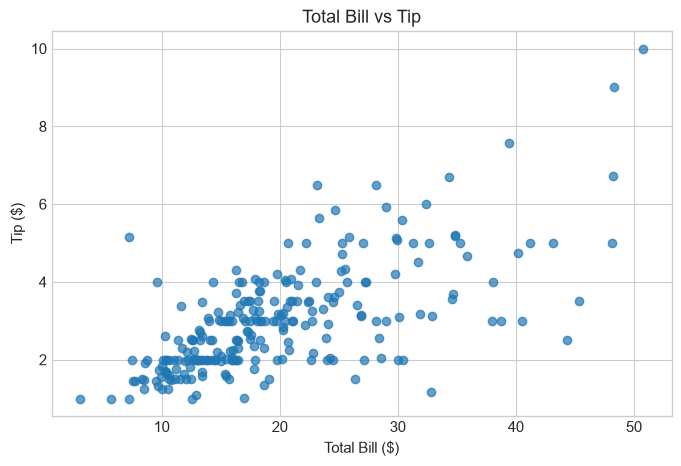

Correlation between total_bill and tip: 0.676


In [31]:
plt.scatter(analysis_df['total_bill'], analysis_df['tip'], alpha=0.7)
plt.title('Total Bill vs Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

correlation = analysis_df['total_bill'].corr(analysis_df['tip'])
print('Correlation between total_bill and tip:', round(correlation, 3))

### Interpretation

The scatter plot usually shows an upward pattern: larger bills often receive larger tips. The correlation is about 0.68, which suggests a clear positive relationship.

However, the points are not perfectly lined up. Customers with similar bill amounts can still leave different tip amounts.

## 8. Question 3: How Do Tips Change by Day?

We will compare:

- Number of tables
- Average bill
- Average tip
- Average tip rate

In [32]:
day_summary = analysis_df.groupby('day').agg(
    table_count=('tip', 'count'),
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_tip_rate=('tip_rate', 'mean')
).round(3)

day_summary

,table_count,avg_bill,avg_tip,avg_tip_rate
day,,,,
Fri,19,17.152,2.735,0.170
Sat,87,20.441,2.993,0.153
Sun,76,21.410,3.255,0.167
Thur,62,17.683,2.771,0.161


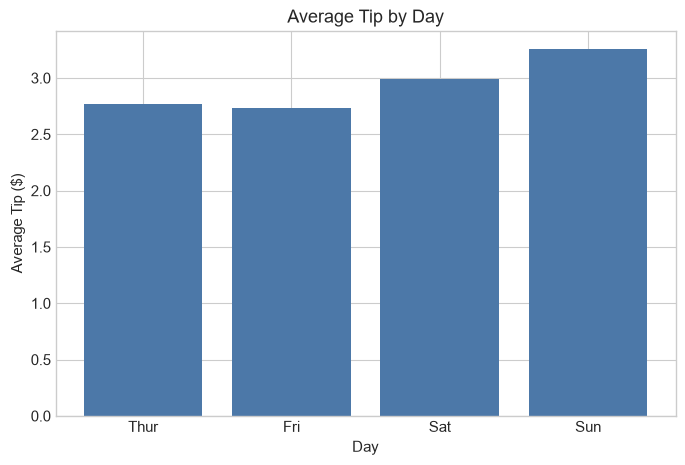

In [33]:
order = ['Thur', 'Fri', 'Sat', 'Sun']
day_tip = day_summary.reindex(order)['avg_tip']

plt.bar(day_tip.index, day_tip.values, color='#4C78A8')
plt.title('Average Tip by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip ($)')
plt.show()

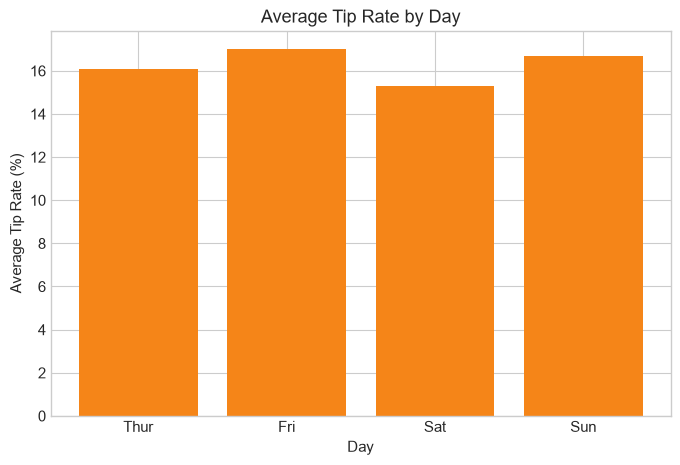

In [34]:
day_tip_rate = day_summary.reindex(order)['avg_tip_rate'] * 100

plt.bar(day_tip_rate.index, day_tip_rate.values, color='#F58518')
plt.title('Average Tip Rate by Day')
plt.xlabel('Day')
plt.ylabel('Average Tip Rate (%)')
plt.show()

### Interpretation

Sunday usually has a higher average tip amount. But this may be because Sunday tables have larger bills or more people.

When we compare tip rate, the difference between days becomes smaller. This is an important lesson:

> A higher tip amount does not always mean customers are more generous. It may simply mean the bill is larger.

## 9. Question 4: Lunch vs Dinner

Now we compare `Lunch` and `Dinner`.

In [35]:
time_summary = analysis_df.groupby('time').agg(
    table_count=('tip', 'count'),
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_tip_rate=('tip_rate', 'mean'),
    avg_size=('size', 'mean')
).round(3)

time_summary

,table_count,avg_bill,avg_tip,avg_tip_rate,avg_size
time,,,,,
Dinner,176,20.797,3.103,0.160,2.631
Lunch,68,17.169,2.728,0.164,2.412


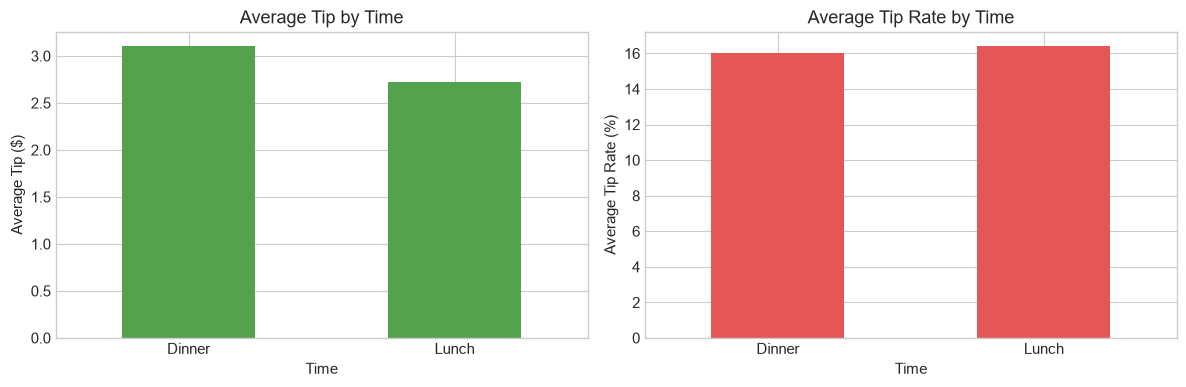

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

time_summary['avg_tip'].plot(kind='bar', ax=axes[0], color='#54A24B')
axes[0].set_title('Average Tip by Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Average Tip ($)')
axes[0].tick_params(axis='x', rotation=0)

time_summary['avg_tip_rate'].mul(100).plot(kind='bar', ax=axes[1], color='#E45756')
axes[1].set_title('Average Tip Rate by Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Average Tip Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

Dinner usually has a higher average bill and a higher average tip. But the tip rate for lunch and dinner is fairly similar.

This shows why we should compare both tip amount and tip rate.

## 10. Question 5: Party Size and Tips

Next, we compare party size with both tip amount and tip rate.

In [37]:
size_summary = analysis_df.groupby('size').agg(
    table_count=('tip', 'count'),
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_tip_rate=('tip_rate', 'mean')
).round(3)

size_summary

,table_count,avg_bill,avg_tip,avg_tip_rate
size,,,,
1,4,7.242,1.438,0.217
2,156,16.448,2.582,0.166
3,38,23.278,3.393,0.152
4,37,28.614,4.135,0.146
5,5,30.068,4.028,0.141
6,4,34.830,5.225,0.156


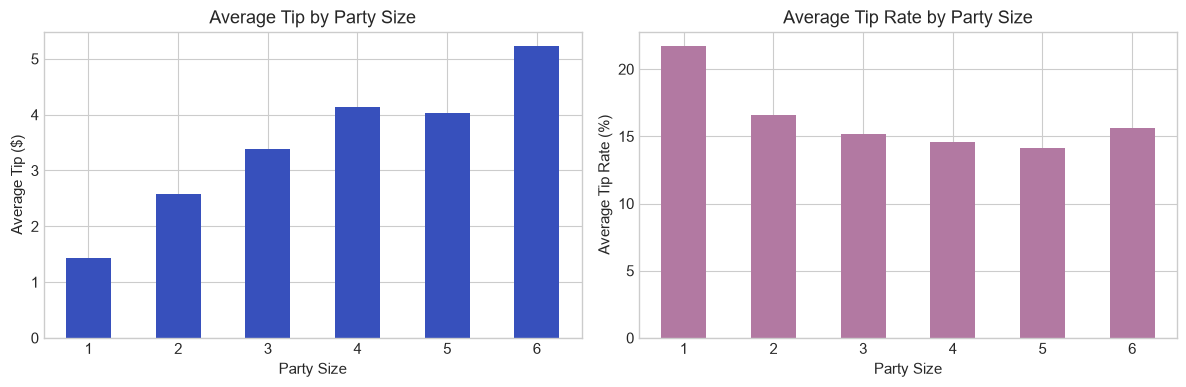

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

size_summary['avg_tip'].plot(kind='bar', ax=axes[0], color="#3750BC")
axes[0].set_title('Average Tip by Party Size')
axes[0].set_xlabel('Party Size')
axes[0].set_ylabel('Average Tip ($)')
axes[0].tick_params(axis='x', rotation=0)

size_summary['avg_tip_rate'].mul(100).plot(kind='bar', ax=axes[1], color='#B279A2')
axes[1].set_title('Average Tip Rate by Party Size')
axes[1].set_xlabel('Party Size')
axes[1].set_ylabel('Average Tip Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

Larger parties often have larger bills and higher tip amounts. But their tip rate is not always higher.

This means larger tables may bring in more total tip dollars, but they do not always tip a higher percentage.

## 11. Gender and Smoking Status

This section is for practicing how to compare categorical variables.

Be careful with interpretation. Small differences should not be exaggerated.

In [39]:
sex_summary = analysis_df.groupby('sex').agg(
    table_count=('tip', 'count'),
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_tip_rate=('tip_rate', 'mean')
).round(3)

smoker_summary = analysis_df.groupby('smoker').agg(
    table_count=('tip', 'count'),
    avg_bill=('total_bill', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_tip_rate=('tip_rate', 'mean')
).round(3)

print('By sex:')
display(sex_summary)

print('By smoker:')
display(smoker_summary)

By sex:


,table_count,avg_bill,avg_tip,avg_tip_rate
sex,,,,
Female,87,18.057,2.833,0.166
Male,157,20.744,3.090,0.158


By smoker:


,table_count,avg_bill,avg_tip,avg_tip_rate
smoker,,,,
No,151,19.188,2.992,0.159
Yes,93,20.756,3.009,0.163


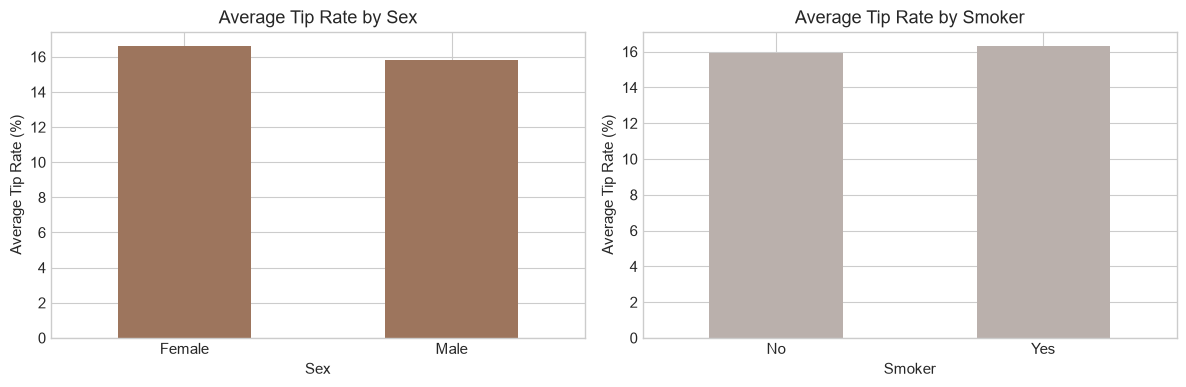

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sex_summary['avg_tip_rate'].mul(100).plot(kind='bar', ax=axes[0], color='#9D755D')
axes[0].set_title('Average Tip Rate by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Average Tip Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

smoker_summary['avg_tip_rate'].mul(100).plot(kind='bar', ax=axes[1], color='#BAB0AC')
axes[1].set_title('Average Tip Rate by Smoker')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Average Tip Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The differences in tip rate by gender and smoking status are small. For a beginner EDA project, this is a useful lesson:

> Seeing a small difference does not automatically mean the difference is important.

## 12. Box Plot: Tip Distribution by Day

Averages are useful, but they do not show the whole distribution.

A box plot helps us see:

- The median
- The spread of the data
- Possible outliers

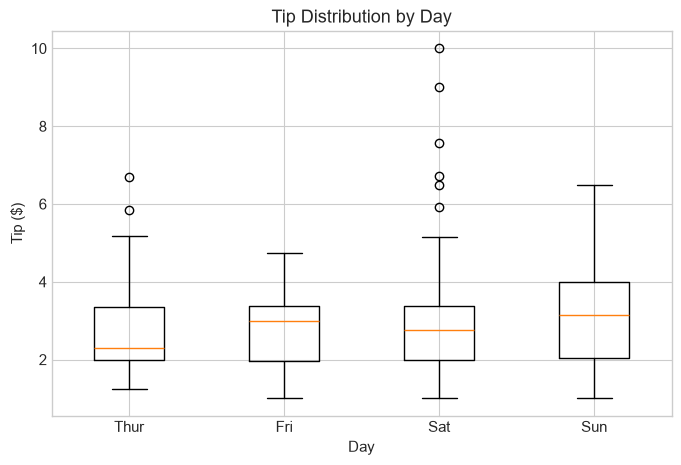

In [42]:
box_data = [analysis_df.loc[analysis_df['day'] == day, 'tip'] for day in order]

plt.boxplot(box_data, tick_labels=order)
plt.title('Tip Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Tip ($)')
plt.show()

### Interpretation

The box plot shows that tip distributions overlap across days. Even if one day has a higher average, it does not mean every table on that day gives a higher tip.

This is another important EDA lesson:

> Do not rely only on averages. Always look at the distribution.

## 13. Correlation Analysis

Finally, we compare the numerical columns using correlation.

In [ ]:
numeric_cols = ['total_bill', 'tip', 'size', 'price_per_person', 'tip_rate']
corr_matrix = analysis_df[numeric_cols].corr().round(3)
corr_matrix

,total_bill,tip,size,price_per_person,tip_rate
total_bill,1.000,0.676,0.598,0.648,-0.339
tip,0.676,1.000,0.489,0.347,0.342
size,0.598,0.489,1.000,-0.175,-0.143
price_per_person,0.648,0.347,-0.175,1.000,-0.314
tip_rate,-0.339,0.342,-0.143,-0.314,1.000


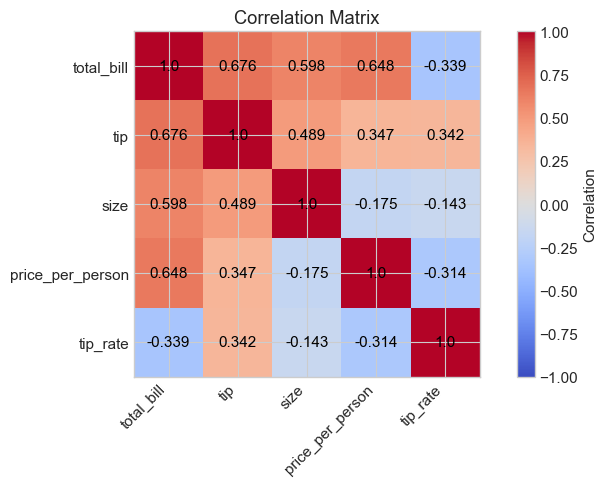

In [ ]:
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Matrix')

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, corr_matrix.iloc[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

### Interpretation

`total_bill` and `tip` have the strongest positive relationship. This suggests that bill amount is one of the most important factors related to tip amount.

However, `tip_rate` does not increase in the same way. A larger bill often means a larger tip amount, but not always a larger tip percentage.

## 14. Hypothesis Testing: Is Dinner Really Different from Lunch?

Charts help us see patterns, but statistics helps us check whether a difference is strong enough to take seriously.

Before running the hypothesis test, we will compare the **distributions** of lunch and dinner. This is a better visual match for hypothesis testing than only comparing two bars.

A t-test asks whether the difference between two group averages is large compared with the natural variation inside the groups. So we want to look at:

1. How far apart the two group centers are
2. How much the two distributions overlap
3. Whether the difference looks large relative to the spread

We will use a **Welch two-sample t-test**. This test compares the average value of two groups. Welch's version is a good beginner-friendly choice because it does not require the two groups to have the same variance.

### Test A: Average Bill Amount

- Null hypothesis: Lunch and dinner have the same average `total_bill`.
- Alternative hypothesis: Lunch and dinner have different average `total_bill`.

### Test B: Average Tip Rate

- Null hypothesis: Lunch and dinner have the same average `tip_rate`.
- Alternative hypothesis: Lunch and dinner have different average `tip_rate`.

We will use a significance level of `0.05`.


### Distribution Comparison Before Testing

The first plot compares the distribution of bill amounts for lunch and dinner. The second plot compares the distribution of tip rates.

The dashed vertical lines show the group means. If the means are far apart and the distributions do not overlap too much, the t-test is more likely to find a statistically meaningful difference.


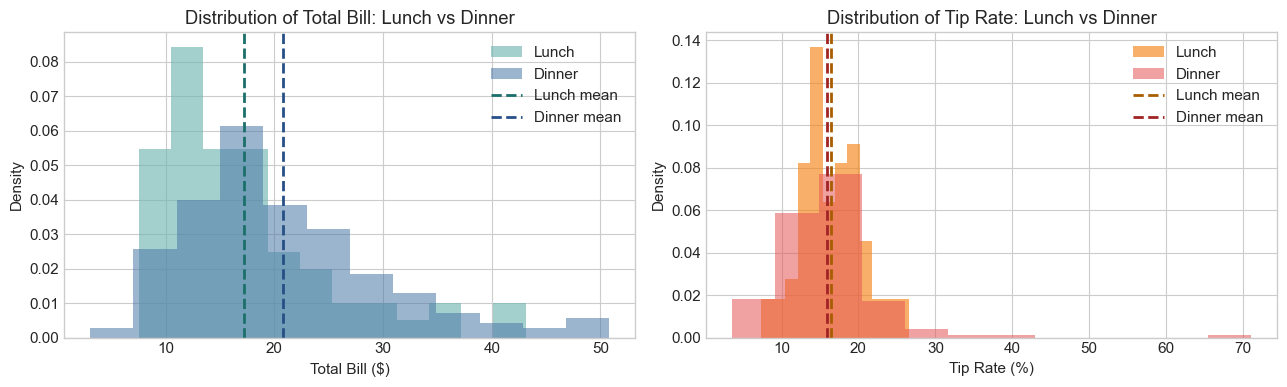

In [ ]:
lunch_bills = analysis_df.loc[analysis_df['time'] == 'Lunch', 'total_bill']
dinner_bills = analysis_df.loc[analysis_df['time'] == 'Dinner', 'total_bill']

lunch_tip_rate = analysis_df.loc[analysis_df['time'] == 'Lunch', 'tip_rate']
dinner_tip_rate = analysis_df.loc[analysis_df['time'] == 'Dinner', 'tip_rate']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lunch_bills, bins=12, alpha=0.65, density=True, label='Lunch', color='#72B7B2')
axes[0].hist(dinner_bills, bins=12, alpha=0.55, density=True, label='Dinner', color='#4C78A8')
axes[0].axvline(lunch_bills.mean(), color='#1B6F6A', linestyle='--', linewidth=2, label='Lunch mean')
axes[0].axvline(dinner_bills.mean(), color='#264F86', linestyle='--', linewidth=2, label='Dinner mean')
axes[0].set_title('Distribution of Total Bill: Lunch vs Dinner')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(lunch_tip_rate * 100, bins=12, alpha=0.65, density=True, label='Lunch', color='#F58518')
axes[1].hist(dinner_tip_rate * 100, bins=12, alpha=0.55, density=True, label='Dinner', color='#E45756')
axes[1].axvline(lunch_tip_rate.mean() * 100, color='#A85D00', linestyle='--', linewidth=2, label='Lunch mean')
axes[1].axvline(dinner_tip_rate.mean() * 100, color='#A12424', linestyle='--', linewidth=2, label='Dinner mean')
axes[1].set_title('Distribution of Tip Rate: Lunch vs Dinner')
axes[1].set_xlabel('Tip Rate (%)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()


### What the Distributions Suggest

For `total_bill`, the dinner distribution is shifted to the right compared with the lunch distribution. The two groups still overlap, but the dinner mean is clearly higher.

For `tip_rate`, the lunch and dinner distributions overlap heavily, and the two mean lines are very close. Visually, this does not look like a strong difference.

The t-tests below help us confirm these visual observations with p-values.


In [ ]:
lunch_bills = analysis_df.loc[analysis_df['time'] == 'Lunch', 'total_bill']
dinner_bills = analysis_df.loc[analysis_df['time'] == 'Dinner', 'total_bill']

bill_t_stat, bill_p_value = stats.ttest_ind(lunch_bills, dinner_bills, equal_var=False)

print('Lunch average bill:', round(lunch_bills.mean(), 2))
print('Dinner average bill:', round(dinner_bills.mean(), 2))
print('t-statistic:', round(bill_t_stat, 3))
print('p-value:', round(bill_p_value, 4))

Lunch average bill: 17.17
Dinner average bill: 20.8
t-statistic: -3.123
p-value: 0.0022


### Interpretation for Test A

If the p-value is less than `0.05`, we reject the null hypothesis.

In this dataset, the p-value is usually around `0.002`, which is below `0.05`. This means the data supports the idea that dinner bills are significantly different from lunch bills. Dinner bills are higher on average.

In [ ]:
lunch_tip_rate = analysis_df.loc[analysis_df['time'] == 'Lunch', 'tip_rate']
dinner_tip_rate = analysis_df.loc[analysis_df['time'] == 'Dinner', 'tip_rate']

tip_rate_t_stat, tip_rate_p_value = stats.ttest_ind(lunch_tip_rate, dinner_tip_rate, equal_var=False)

print('Lunch average tip rate:', round(lunch_tip_rate.mean() * 100, 2), '%')
print('Dinner average tip rate:', round(dinner_tip_rate.mean() * 100, 2), '%')
print('t-statistic:', round(tip_rate_t_stat, 3))
print('p-value:', round(tip_rate_p_value, 4))

Lunch average tip rate: 16.41 %
Dinner average tip rate: 15.95 %
t-statistic: 0.654
p-value: 0.5138


### Interpretation for Test B

In this dataset, the p-value is usually around `0.51`, which is much higher than `0.05`. This means we do not have strong evidence that lunch and dinner have different average tip rates.

This is an important project finding:

> Dinner has higher tip amounts, but not a significantly higher tip rate.

So, the higher dinner tips are likely connected to larger dinner bills, not necessarily a different tipping habit.

## 15. Final Project Conclusion

Let's return to the main analysis question:

> **Are customers tipping differently across restaurant situations, or are larger tips mostly explained by larger bills?**

Based on this EDA and hypothesis testing, we can conclude:

1. **Tip amount is strongly related to total bill amount.** Larger bills usually receive larger tips.
2. **Dinner has significantly higher average bills than lunch**, and it also has a higher average tip amount.
3. **Dinner does not have a significantly different average tip rate from lunch.** This suggests that larger dinner tips are mostly connected to larger dinner bills, not necessarily a higher tipping percentage.
4. **Day of week and party size are useful for describing restaurant activity**, but tip rate is still more stable than raw tip amount.
5. **Smoking status and gender show only small tip-rate differences in this dataset**, so we should avoid making strong claims about them.

## Business Recommendation

The restaurant should use this analysis to understand revenue and staffing patterns, not to stereotype customers.

1. Dinner and weekend shifts may need more staffing because they often involve larger bills and higher total tips.
2. Servers may earn more total tip dollars from larger tables and larger bills, but tip percentage is not automatically higher.
3. The restaurant should measure both `tip` and `tip_rate`. Looking only at tip amount can lead to a misleading conclusion.
4. The most defensible conclusion is: **larger bills explain much of the increase in tip amount, while tip rate gives a fairer comparison of tipping behavior.**

## One-Sentence Summary

**This project shows that larger tips are mostly associated with larger bills, while tip rate is the better metric for comparing customer tipping behavior.**
